In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('state_data.csv')

In [3]:
print(df.shape)  # Output: (rows, columns)

(52, 4)


In [4]:
print(df.head())   # First 5 rows
print(df.tail())   # Last 5 rows
# The columns represent: state name, population, region, etc.
# The first state is: Alabama
# The last state is: Wyoming
# Total entries: 52
# There are more than 50 states because D.C. and territories are included

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [5]:
median_lat = df['latitude'].median()
median_lon = df['longitude'].median()

print(f"Median Latitude: {median_lat}")
print(f"Median Longitude: {median_lon}")

Median Latitude: 39.4355155
Median Longitude: -89.093198


In [6]:
df['dist_from_median_lat'] = (df['latitude'] - median_lat).abs()

In [7]:
df['dist_from_median_lon'] = (df['longitude'] - median_lon).abs()

In [8]:
print(df.shape)  # show 2 extra columns

(52, 6)


In [9]:
# Median Latitude
closest_lat = df.loc[df['dist_from_median_lat'].idxmin()]
farthest_lat = df.loc[df['dist_from_median_lat'].idxmax()]

# Median Longitude
closest_lon = df.loc[df['dist_from_median_lon'].idxmin()]
farthest_lon = df.loc[df['dist_from_median_lon'].idxmax()]

print(f"Closest to median latitude: {closest_lat['state']} by {closest_lat['dist_from_median_lat']:.2f}")
print(f"Farthest from median latitude: {farthest_lat['state']} by {farthest_lat['dist_from_median_lat']:.2f}")
print(f"Closest to median longitude: {closest_lon['state']} by {closest_lon['dist_from_median_lon']:.2f}")
print(f"Farthest from median longitude: {farthest_lon['state']} by {farthest_lon['dist_from_median_lon']:.2f}")

Closest to median latitude: CO by 0.11
Farthest from median latitude: AK by 24.15
Closest to median longitude: IL by 0.31
Farthest from median longitude: HI by 66.57


In [10]:
df.corr(numeric_only=True)
# I found the df.corr() function on the Pandas documentation website at https://pandas.pydata.org/docs/. I navigated to API Reference → DataFrame → Computations / descriptive stats, where DataFrame.corr is listed.
# The function computes the pairwise correlation between all numeric columns in the DataFrame.
# It is helpful when you want to see if two variables have a relationship.

,latitude,longitude,dist_from_median_lat,dist_from_median_lon
latitude,1.000000,-0.161095,-0.153138,0.156215
longitude,-0.161095,1.000000,-0.420898,-0.702718
dist_from_median_lat,-0.153138,-0.420898,1.000000,0.572034
dist_from_median_lon,0.156215,-0.702718,0.572034,1.000000


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df2 = sns.load_dataset('penguins')

In [13]:
df2 = df2.dropna(axis=0)
print(df2.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  


In [14]:
# Shape
print(df2.shape)

# First and last 5 rows
print(df2.head())
print(df2.tail())

# Column names
print(df2.columns)

(333, 7)
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  
    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
338  Gentoo  Biscoe            47.2           13.7              214.0   
340  Gentoo  Biscoe            46.8           14.3              215.0   
341  Gentoo  Biscoe            50.4           15.7              222.0   
342  Gentoo  Biscoe            45.2           14.8              212.0   
343  Gentoo  Biscoe            

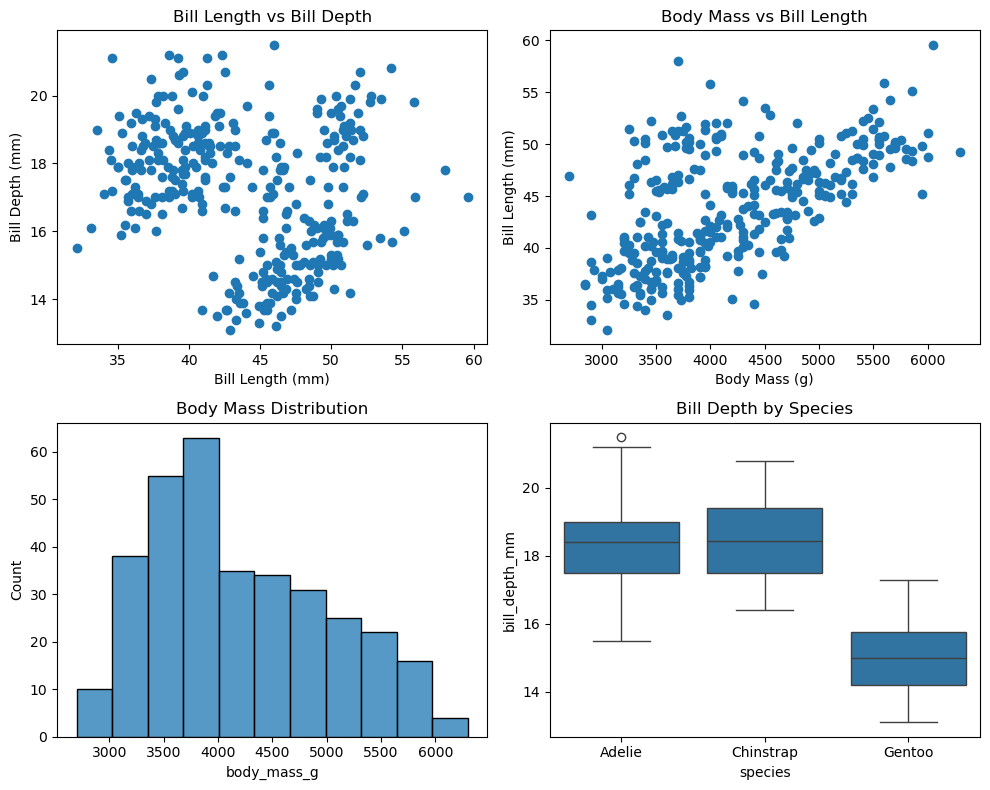

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Top-left: Scatter plot (2 columns)
axes[0, 0].scatter(df2['bill_length_mm'], df2['bill_depth_mm'])
axes[0, 0].set_title('Bill Length vs Bill Depth')
axes[0, 0].set_xlabel('Bill Length (mm)')
axes[0, 0].set_ylabel('Bill Depth (mm)')

# Top-right: Scatter plot (2 different columns)
axes[0, 1].scatter(df2['body_mass_g'], df2['bill_length_mm'])
axes[0, 1].set_title('Body Mass vs Bill Length')
axes[0, 1].set_xlabel('Body Mass (g)')
axes[0, 1].set_ylabel('Bill Length (mm)')

# Bottom-left: Histogram
sns.histplot(df2['body_mass_g'], ax=axes[1, 0])
axes[1, 0].set_title('Body Mass Distribution')

# Bottom-right: Boxplot
sns.boxplot(x=df2['species'], y=df2['bill_depth_mm'], ax=axes[1, 1])
axes[1, 1].set_title('Bill Depth by Species')

plt.tight_layout()
plt.show()

C:\Users\nicol\AppData\Local\Temp\ipykernel_23532\3677025293.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df2['species'], y=df2['bill_depth_mm'], ax=axes[1, 1],


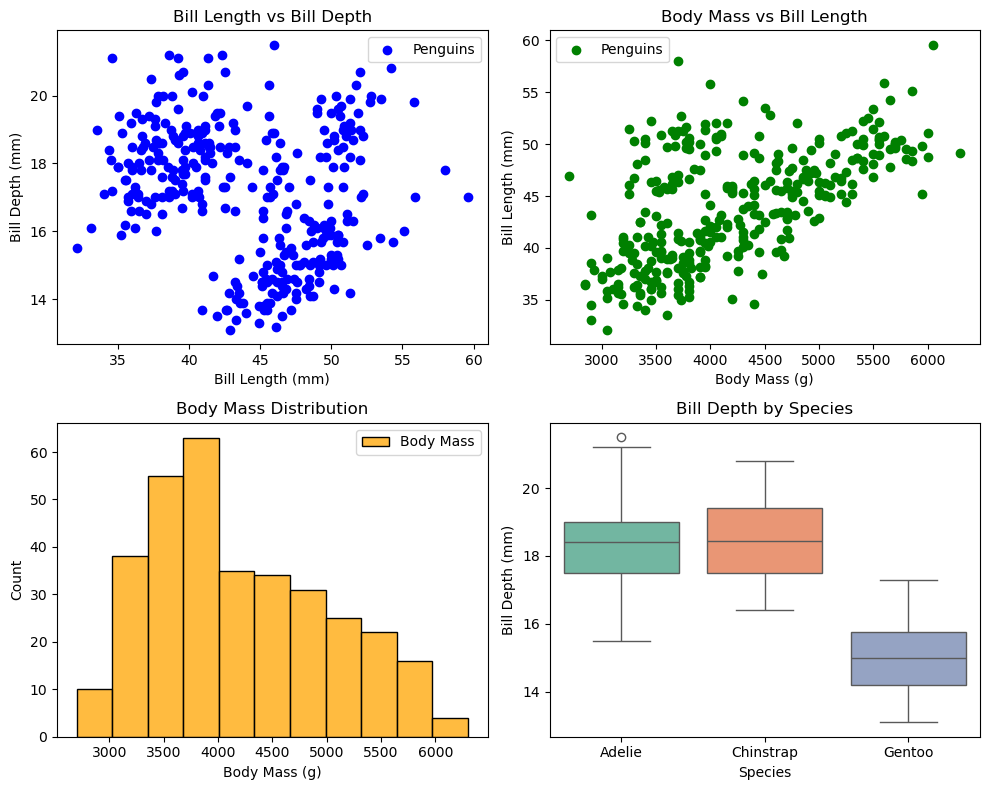

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Top-left: Scatter plot
scatter1 = axes[0, 0].scatter(df2['bill_length_mm'], df2['bill_depth_mm'], 
                               color='blue', label='Penguins')
axes[0, 0].set_title('Bill Length vs Bill Depth')
axes[0, 0].set_xlabel('Bill Length (mm)')
axes[0, 0].set_ylabel('Bill Depth (mm)')
axes[0, 0].legend()

# Top-right: Scatter plot
scatter2 = axes[0, 1].scatter(df2['body_mass_g'], df2['bill_length_mm'], 
                               color='green', label='Penguins')
axes[0, 1].set_title('Body Mass vs Bill Length')
axes[0, 1].set_xlabel('Body Mass (g)')
axes[0, 1].set_ylabel('Bill Length (mm)')
axes[0, 1].legend()

# Bottom-left: Histogram
sns.histplot(df2['body_mass_g'], ax=axes[1, 0], color='orange', label='Body Mass')
axes[1, 0].set_title('Body Mass Distribution')
axes[1, 0].set_xlabel('Body Mass (g)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# Bottom-right: Boxplot
sns.boxplot(x=df2['species'], y=df2['bill_depth_mm'], ax=axes[1, 1], 
            palette='Set2')
axes[1, 1].set_title('Bill Depth by Species')
axes[1, 1].set_xlabel('Species')
axes[1, 1].set_ylabel('Bill Depth (mm)')

plt.tight_layout()
plt.show()

In [17]:
# Top-left (Bill Length vs Bill Depth):
# I chose these two columns because both measure physical bill dimensions,
# so I wanted to see if longer bills are also deeper. The scatter plot shows
# a slight negative relationship, Adelie penguins tend to have shorter but
# deeper bills compared to Gentoo penguins.

# Top-right (Body Mass vs Bill Length):
# I chose these columns to see if heavier penguins tend to have longer bills.
# The plot shows a positive trend that heavier penguins generally have longer bills,
# suggesting overall body size affects bill size.

# Bottom-left (Body Mass Distribution)
# I chose body mass to see how weight is spread across all penguins. The 
# histogram shows a roughly normal distribution centered around 4000g, with 
# some heavier outliers likely being Gentoo penguins.

# Bottom-right (Bill Depth by Species):
# I chose this to compare bill depth across the three species. The boxplot 
# clearly shows Adelie penguins have the deepest bills, while Gentoo penguins 
# have the shallowest, with Chinstrap in between.